In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sympy.physics.wigner import wigner_3j, wigner_6j
from scipy import linalg

In [ ]:
hbar = 6.62607015*10**-34 / (2*np.pi) # Joules seconds
h = hbar*2*np.pi # J seconds
A_hfs = h*3.417341e9 # J, for ground state 5S_1/2

g = 2.00233107 # no units
u_B = 9.274010e-24 # J/T
B = np.linspace(0, 15000/10000, 1000) # T

Note: use hash tables to define all wigner 3j/6j at the beginning of the code to speed things up

In [ ]:
# for a given energy (M, M') in the matrix
def get_matrix_element(M, M_p, F, F_p, I, S, B):
    if (F == F_p) & (M==M_p):
        hyperfine_element = A_hfs/(hbar**2) * (F*(F+1)-I*(I+1)-S*(S+1))*hbar**2/2
    else:
        hyperfine_element = 0

    spherical_element = (-1)**(-M+F+F_p+I+S+1) * hbar * np.sqrt((2*F+1)*(2*F_p+1)) * wigner_3j(F,1,F_p,-M,0,M_p) * wigner_6j(S,F_p,I,F,S,1) * np.sqrt(S*(S+1)*(2*S+1))
    mag_element = -1*u_B*g*B*spherical_element/hbar

    return mag_element + hyperfine_element

In [ ]:
I, S = 3/2, 1/2
M = np.array([-1, 0, 1, -2, -1, 0, 1, 2])
M_pv, Mv = np.meshgrid(M, M)

F = np.array([1,1,1,2,2,2,2,2])
F_pv, Fv = np.meshgrid(F, F)

#print(M_pv)
#print(Mv)
#print(F_pv)
#print(Fv)
 
eig_arr = []
for B_val in B:
    H = np.zeros((8, 8))
    for i in range(0, 8):
        for j in range(0, 8):
            F, F_p = Fv[i,j], F_pv[i,j]
            M, M_p = Mv[i,j], M_pv[i,j]
            H[i][j] = get_matrix_element(M, M_p, F, F_p, I, S, B_val)
    eigenvalues = linalg.eigvals(H) 
    #eigenvalues, eigenvectors = np.linalg.eig(H)
    
    eig_arr.append(eigenvalues)

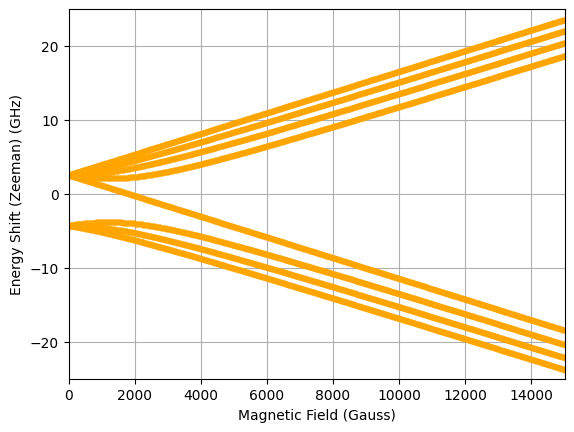

In [ ]:
eig_arr = np.array(eig_arr)

for i in range(0, 8):
    plt.plot(B*10000, eig_arr[:,i]/h/1e9, '.', color='orange')

plt.ylim([-25, 25])
plt.xlim([0, 15000])
plt.xlabel('Magnetic Field (Gauss)')
plt.ylabel('Energy Shift (Zeeman) (GHz)')
plt.grid()